In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/processed/carbon_intensity.parquet')
df['interval_start_utc'] = pd.to_datetime(df['interval_start_utc'], utc=True)
df = df.sort_values('interval_start_utc').reset_index(drop=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30216 entries, 0 to 30215
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   interval_start_utc  30216 non-null  datetime64[ns, UTC]
 1   nuclear             30216 non-null  float64            
 2   hydro               30216 non-null  float64            
 3   wind                30216 non-null  float64            
 4   solar               30216 non-null  float64            
 5   gas                 30216 non-null  float64            
 6   biofuel             30216 non-null  float64            
 7   other               30216 non-null  float64            
 8   carbon_intensity    30216 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(8)
memory usage: 2.1 MB


In [4]:
print(f"Date range: {df['interval_start_utc'].min()} → {df['interval_start_utc'].max()}")
print(f"Rows: {len(df):,}")
df[['carbon_intensity']].describe()

Date range: 2023-01-01 05:00:00+00:00 → 2026-06-13 04:00:00+00:00
Rows: 30,216


,carbon_intensity
count,30216.000000
mean,93.685751
std,41.829421
min,14.386355
25%,60.859860
50%,94.139158
75%,127.813764
max,202.672654


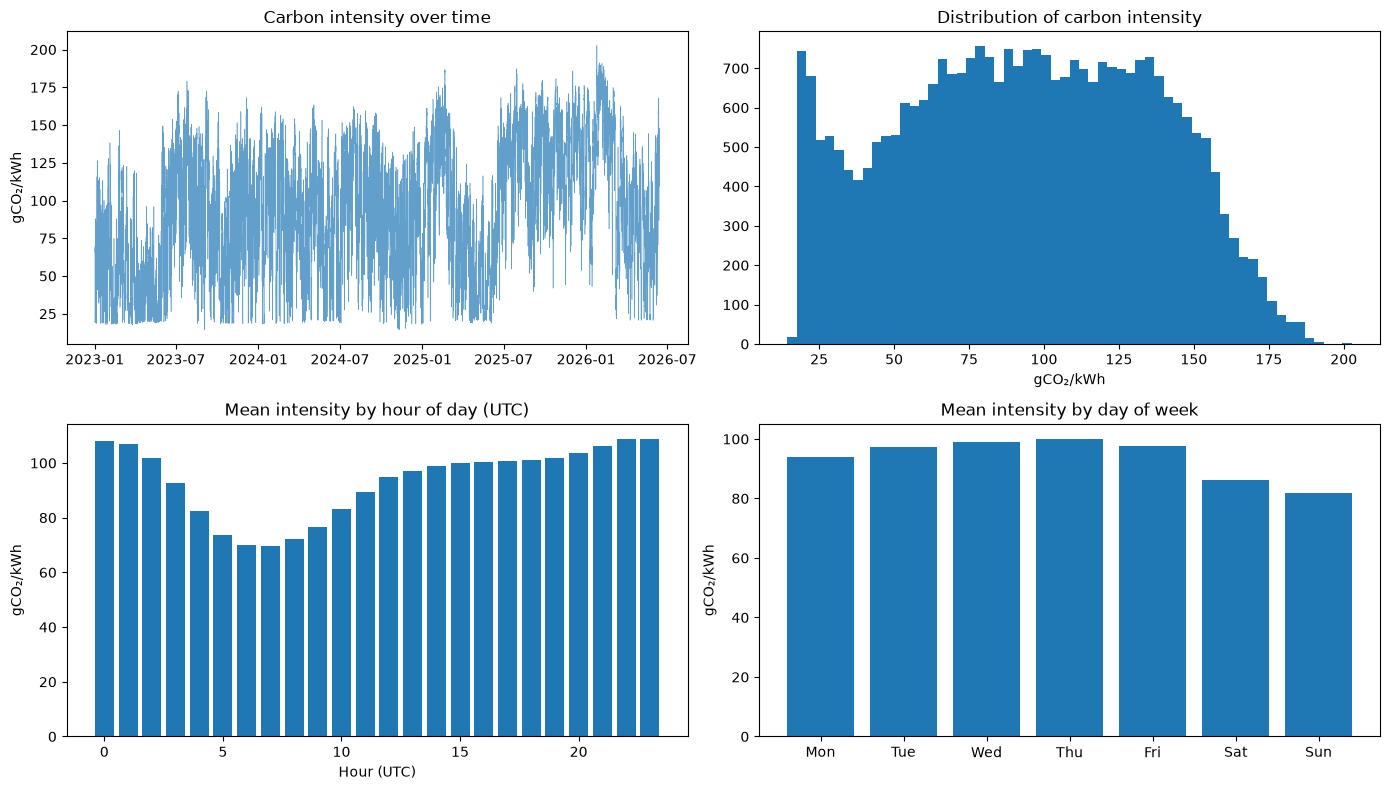

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Full time series
axes[0, 0].plot(df['interval_start_utc'], df['carbon_intensity'], lw=0.4, alpha=0.7)
axes[0, 0].set_title('Carbon intensity over time')
axes[0, 0].set_ylabel('gCO₂/kWh')

# Distribution
axes[0, 1].hist(df['carbon_intensity'], bins=60, edgecolor='none')
axes[0, 1].set_title('Distribution of carbon intensity')
axes[0, 1].set_xlabel('gCO₂/kWh')

# Mean by hour of day (UTC)
df['hour'] = df['interval_start_utc'].dt.hour
hourly = df.groupby('hour')['carbon_intensity'].mean()
axes[1, 0].bar(hourly.index, hourly.values)
axes[1, 0].set_title('Mean intensity by hour of day (UTC)')
axes[1, 0].set_xlabel('Hour (UTC)')
axes[1, 0].set_ylabel('gCO₂/kWh')

# Mean by day of week
df['dow'] = df['interval_start_utc'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly = df.groupby('dow')['carbon_intensity'].mean().reindex(dow_order)
axes[1, 1].bar(range(7), weekly.values)
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels([d[:3] for d in dow_order])
axes[1, 1].set_title('Mean intensity by day of week')
axes[1, 1].set_ylabel('gCO₂/kWh')

plt.tight_layout()
plt.show()

C:\Users\vince\AppData\Local\Temp\ipykernel_28196\3628509944.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['month'] = df['interval_start_utc'].dt.to_period('M')


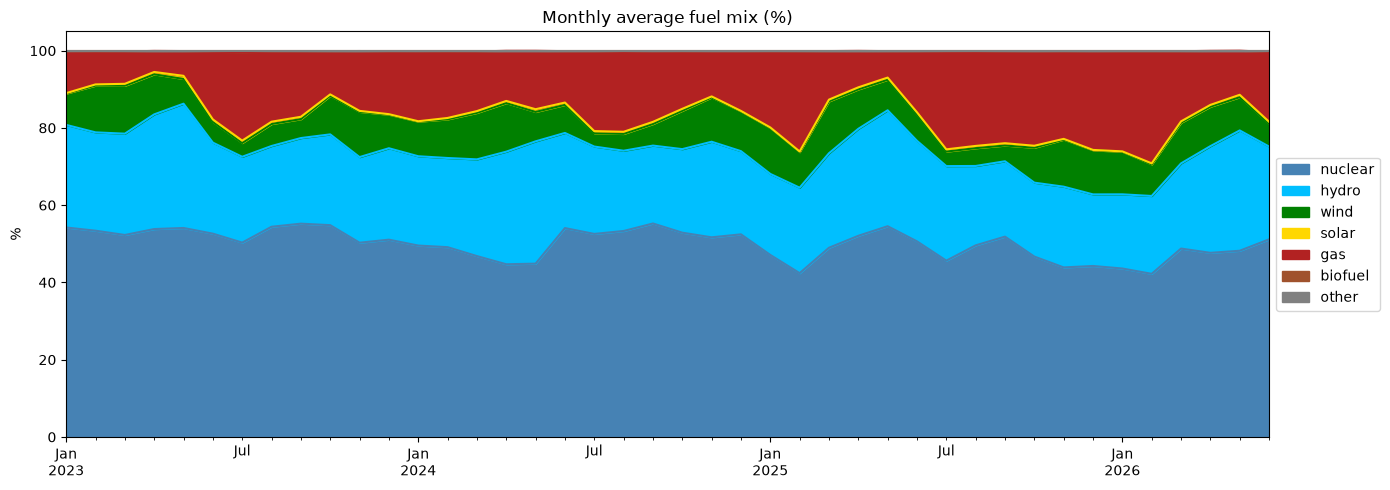

In [6]:
# Fuel mix share over time (monthly average)
fuel_cols = ['nuclear', 'hydro', 'wind', 'solar', 'gas', 'biofuel', 'other']
df['month'] = df['interval_start_utc'].dt.to_period('M')
monthly = df.groupby('month')[fuel_cols].mean()
monthly_pct = monthly.div(monthly.sum(axis=1), axis=0) * 100

monthly_pct.plot(kind='area', stacked=True, figsize=(14, 5),
                 color=['steelblue','deepskyblue','green','gold','firebrick','sienna','gray'])
plt.title('Monthly average fuel mix (%)')
plt.ylabel('%')
plt.xlabel('')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

In [7]:
# Gap check
diffs = df['interval_start_utc'].diff().dropna()
non_hourly = diffs[diffs != pd.Timedelta('1h')]
print(f"Total gaps (non-1h): {len(non_hourly)}")
if not non_hourly.empty:
    print(non_hourly.value_counts().head(10))

Total gaps (non-1h): 0


In [10]:
df.head()

,interval_start_utc,nuclear,hydro,wind,solar,gas,biofuel,other,carbon_intensity,hour,dow,month
0,2023-01-01 05:00:00+00:00,9977.0,4185.0,533.0,0.0,130.0,19.0,0.0,19.812517,5,Sunday,2023-01
1,2023-01-01 06:00:00+00:00,9993.0,3928.0,688.0,0.0,130.0,19.0,0.0,19.638569,6,Sunday,2023-01
2,2023-01-01 07:00:00+00:00,9996.0,3725.0,693.0,0.0,129.0,19.0,0.0,19.540928,7,Sunday,2023-01
3,2023-01-01 08:00:00+00:00,9999.0,3860.0,685.0,0.0,129.0,19.0,0.0,19.585012,8,Sunday,2023-01
4,2023-01-01 09:00:00+00:00,10002.0,3826.0,658.0,0.0,152.0,19.0,0.0,20.327216,9,Sunday,2023-01
